# **Performing EDA on Titanic dataset**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Column Types
- Numerical - PassengerId, Age, Fare
- Categorical - Survived, Pclass, Sex, SipSp, Parch, Embarked
- Mixed - Name, Ticket, Cabin

# Performing Univariate Analysis on Numerical and Categorical columns : 

## **Numerical Columns** ->

## Age column :

In [3]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: ylabel='Frequency'>

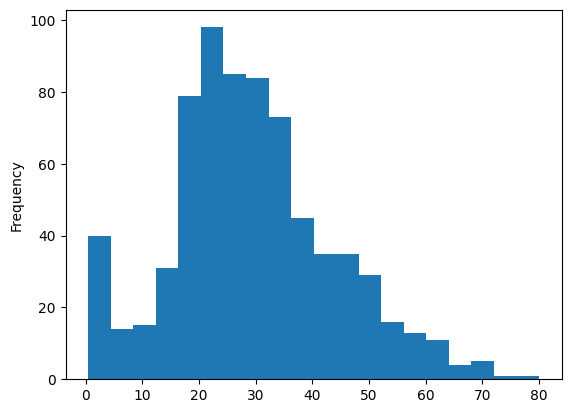

In [4]:
df['Age'].plot(kind='hist', bins=20)

<Axes: ylabel='Density'>

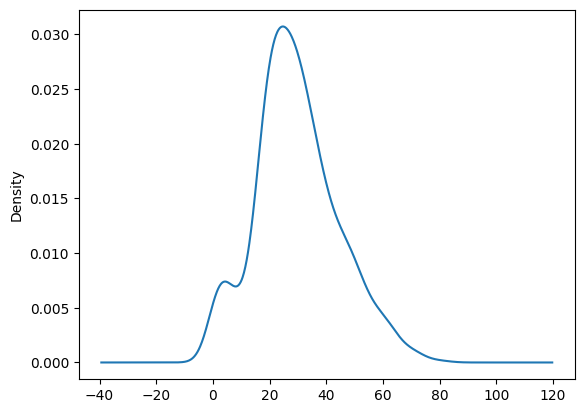

In [5]:
df['Age'].plot(kind='kde')

<Axes: >

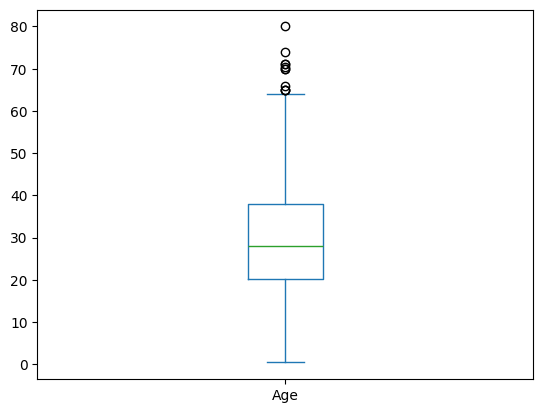

In [6]:
df['Age'].plot(kind='box')

In [7]:
df[df['Age'] > 65]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


In [8]:
print("There are total of",df['Age'].isnull().sum(), "missing age values.")
df['Age'].isnull().sum()/len(df['Age']) * 100

There are total of 177 missing age values.


np.float64(19.865319865319865)

## *Conclusion* on Age column ->
- Age is normally distributed.
- Almost 20% values are missing.
- There are some outliers.

.
## Fare Coumn :

In [9]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: ylabel='Frequency'>

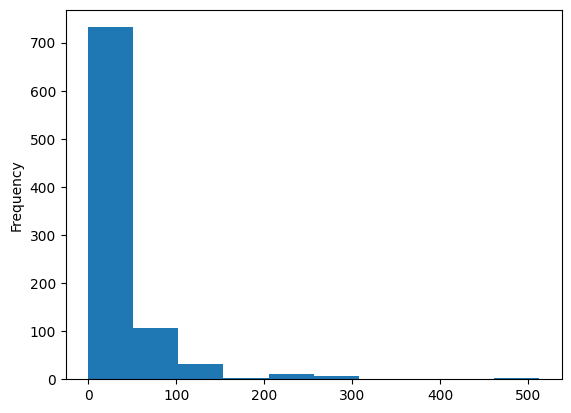

In [10]:
df['Fare'].plot(kind='hist')

<Axes: ylabel='Density'>

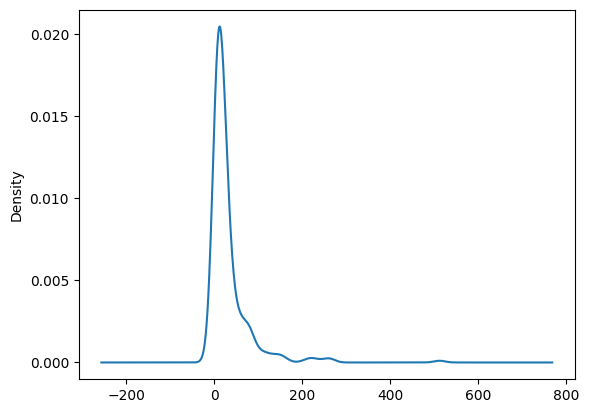

In [11]:
df['Fare'].plot(kind='kde')

In [12]:
df['Fare'].skew()

np.float64(4.787316519674893)

### This data is Highly Positively Skewed

<Axes: >

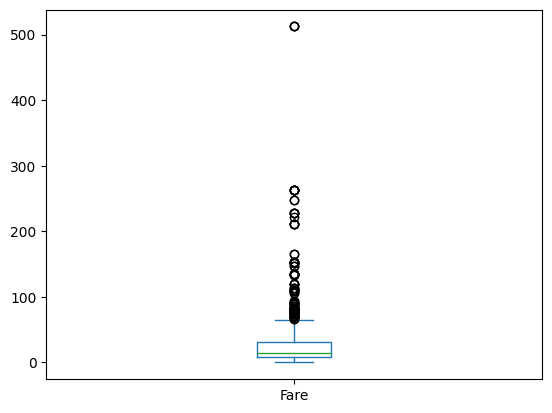

In [13]:
df['Fare'].plot(kind='box')

In [14]:
df[df['Fare'] > 250] 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


In [15]:
df['Fare'].isnull().sum()

np.int64(0)

## *Conclusion* on Fare Column ->
- The data is Highly Skewed (Positively).
- Fare column actually contains the group fare and not the individual fare (This might be an issue).
- To sort this issue we need to do FE for individual fare.

.
## **Categorical Columns** ->

## Survived Column :

In [16]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived'>

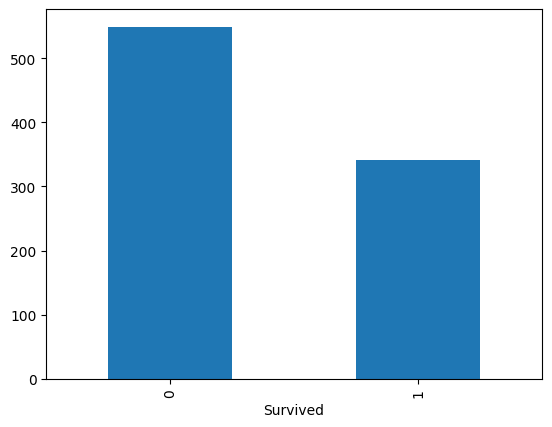

In [17]:
df['Survived'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

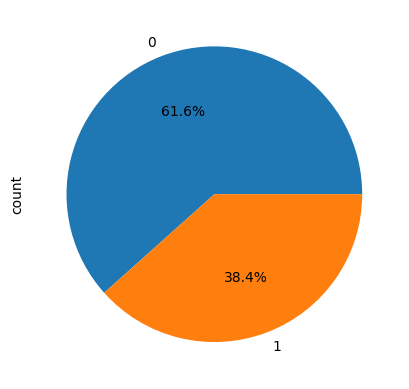

In [18]:
df['Survived'].value_counts().plot(kind='pie', autopct='%0.1f%%')

In [19]:
df['Survived'].isnull().sum()

np.int64(0)

## *Conclusion* on Survived column ->
- More than 50% of people didnt survived.
- There are no missing values.

.
## Pclass column :
- 1 -> Best Class
- 2 -> Better Class
- 3 -> Good Class

In [20]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

<Axes: xlabel='Pclass'>

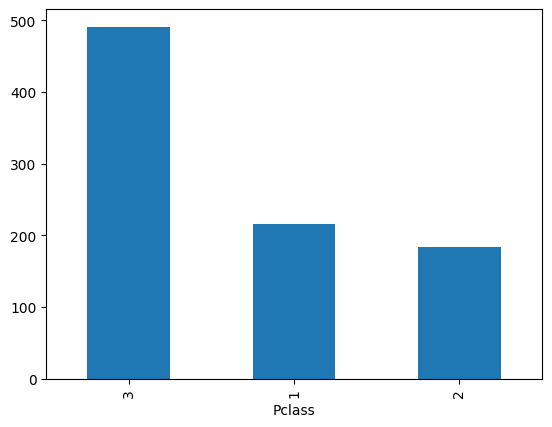

In [21]:
df['Pclass'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

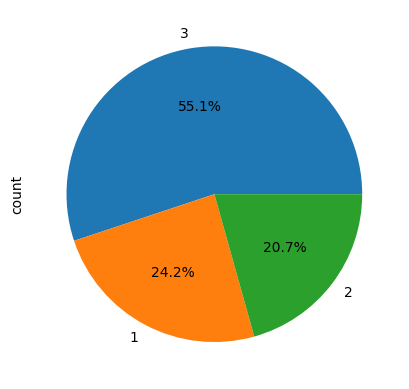

In [22]:
df['Pclass'].value_counts().plot(kind='pie', autopct='%0.1f%%')

In [23]:
df['Pclass'].isnull().sum()

np.int64(0)

## *Conclusion* on Pclass column ->
- There were more passengers travelling in 1st class as compared to 2nd class.
- More than 50% passengers travelled in 3rd class. 
- There are no missing values.

.
## Sex Column ->

In [24]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='Sex'>

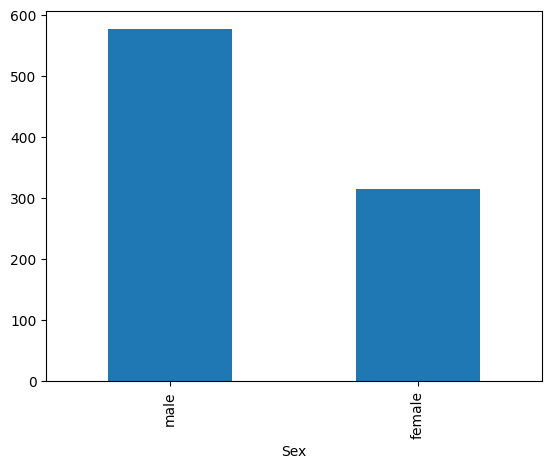

In [25]:
df['Sex'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

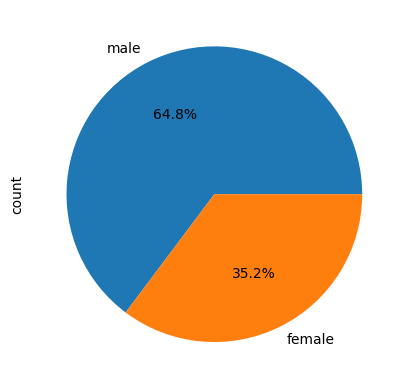

In [26]:
df['Sex'].value_counts().plot(kind='pie', autopct='%0.1f%%')

In [27]:
df['Sex'].isnull().sum()

np.int64(0)

## *Conclusion* on Sex column ->
- This data is absolutely normal. There are usually more number of males as compared to females.
- There are no missing values.

.
## SibSp Column :

In [28]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

<Axes: xlabel='SibSp'>

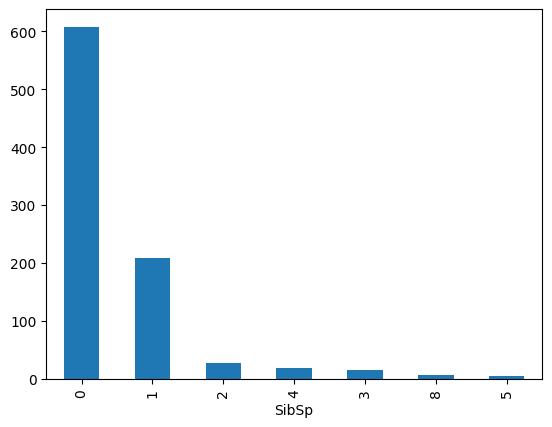

In [29]:
df['SibSp'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

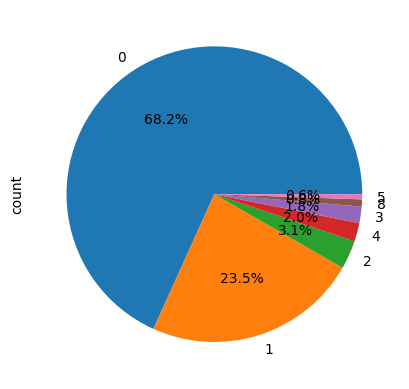

In [30]:
df['SibSp'].value_counts().plot(kind='pie', autopct= '%0.1f%%')

In [31]:
df['SibSp'].isnull().sum()

np.int64(0)

## *Conclusion* on SibSp column->
- This is a normal data, here more than 50% passengers were travelling SOLO.

.
## Parch column :

In [32]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

<Axes: xlabel='Parch'>

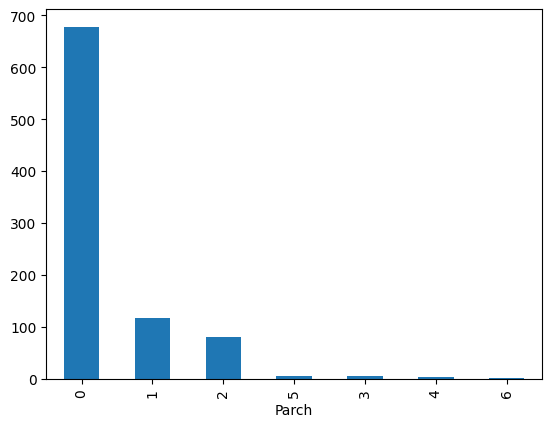

In [33]:
df['Parch'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

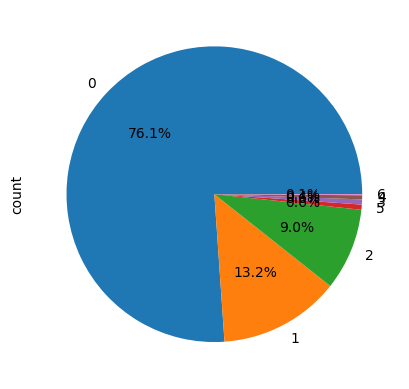

In [34]:
df['Parch'].value_counts().plot(kind='pie', autopct='%0.1f%%')

## *Conclusion* of Parch column ->
- Parch and Sibsp columns can be merged to create a new column as "Familysize".
- Create a new column called is_alone.

.
## Embarked column :
- S - Southampton
- C - Chebourg
- Q - QueensTown

In [35]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

<Axes: xlabel='Embarked'>

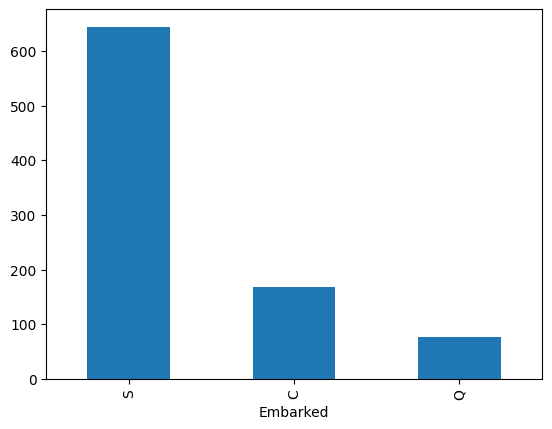

In [36]:
df['Embarked'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

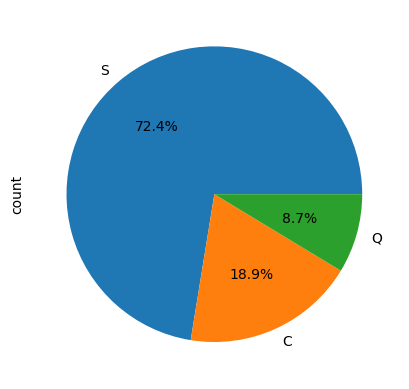

In [37]:
df['Embarked'].value_counts().plot(kind='pie', autopct='%0.1f%%')

In [38]:
df['Embarked'].isnull().sum()

np.int64(2)

## *Conclusion* of Embarked column ->
- There are 2 missing values from the data.


.
# Performing **BI-VARIATE ANALYSIS** ->

## Performing Bivariate analysis on Survived / Pclass ->
### (Categorical - Categorical)

In [39]:
pd.crosstab(df['Survived'],df['Pclass'])        #crosstab is used to create a contingency table 

Pclass,1,2,3
Survived,,,
0,80,97,372
1,136,87,119


In [40]:
# Normalize (index, column, default(false), true(all))

pd.crosstab(df['Survived'],df['Pclass'], normalize='columns') * 100

Pclass,1,2,3
Survived,,,
0,37.037037,52.717391,75.763747
1,62.962963,47.282609,24.236253


<Axes: xlabel='Pclass', ylabel='Survived'>

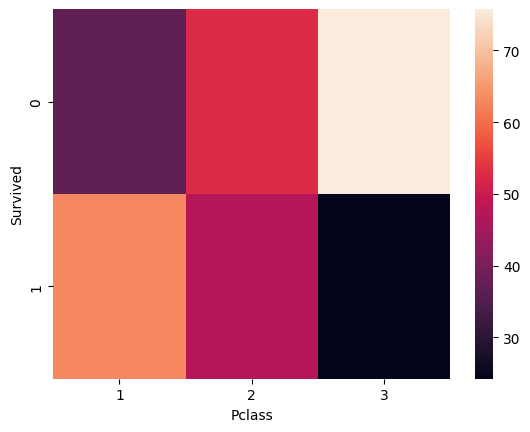

In [41]:
sns.heatmap(pd.crosstab(df['Survived'],df['Pclass'], normalize='columns') * 100)

## *Conclusion* for Survived / Pclass columns ->
- Number of survivors were least in Pclass 3 as compared to other two classes.
- It was too risky to travel in Pclass 3.
- It was safer to travel in Pclass 1.

.
## Performing Bivariate analysis on Survived / Sex ->
### (Categorical - Categorical)

In [42]:
pd.crosstab(df['Survived'],df['Sex'])

Sex,female,male
Survived,,
0,81,468
1,233,109


In [43]:
pd.crosstab(df['Survived'],df['Sex'], normalize='columns') * 100

Sex,female,male
Survived,,
0,25.796178,81.109185
1,74.203822,18.890815


<Axes: xlabel='Sex', ylabel='Survived'>

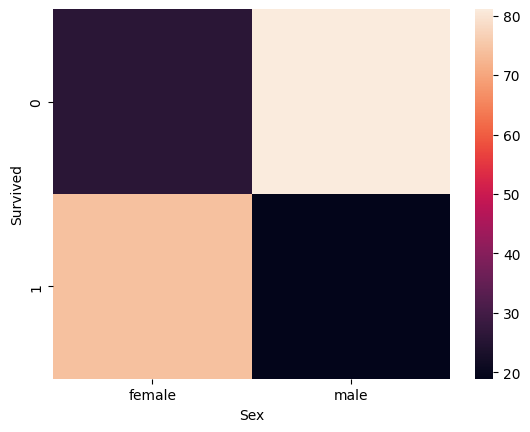

In [44]:
sns.heatmap(pd.crosstab(df['Survived'],df['Sex'], normalize='columns') * 100)

## *Conclusion* for Age / Survived column ->
- Mostly females were survived as compared to the men.
- Females must be given the first priority while rescuing.

.
## Performing bivariate on other columns ->
### (Categorical - Categorical)

In [45]:
pd.crosstab(df['Survived'], df['Embarked'], normalize='columns') * 100

Embarked,C,Q,S
Survived,,,
0,44.642857,61.038961,66.304348
1,55.357143,38.961039,33.695652


In [46]:
pd.crosstab(df['Sex'], df['Embarked'], normalize='columns') * 100

Embarked,C,Q,S
Sex,,,
female,43.452381,46.753247,31.521739
male,56.547619,53.246753,68.478261


In [47]:
pd.crosstab(df['Pclass'], df['Embarked'], normalize='columns') * 100

Embarked,C,Q,S
Pclass,,,
1,50.595238,2.597403,19.720497
2,10.119048,3.896104,25.465839
3,39.285714,93.506494,54.813665


## *Conclusion* ->
- Passengers who embarked at Cherbourg survived most.
- Most of the passengers who embarked at Cherbourg were of Pclass-1.
- As we know on the previous conclusions, Pclass-1 passengers had the most survival rate.

.
## Analyzing Survived & Age Column columns :
### (Categorical & Numerical)

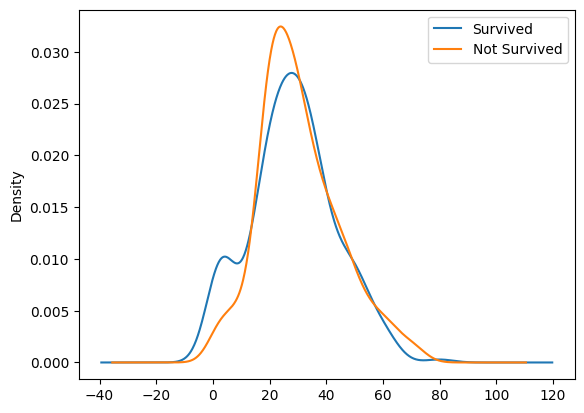

In [48]:
df[df['Survived'] == 1]['Age'].plot(kind='kde', label='Survived')
df[df['Survived'] == 0]['Age'].plot(kind='kde', label='Not Survived')

plt.legend()
plt.show()

In [49]:
df[df['Pclass'] == 1]['Age'].mean()

np.float64(38.233440860215055)

## *Conclusion* ->
- Passengers within age : 0 to 5 yrs have more probablity of Survived.
- Passengers within age : 10 to 40 yrs have more probablity of not surviving.
- Passengers with Pclass-1 have more Survival chances with avg age of 38yrs.
• Passengers with age more then 60 yrs still have slightly less change of survival.

.
## *FEATURE ENGINEERING*

In [50]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [51]:
df[df['SibSp'] == 8]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [52]:
df1 = pd.read_csv("test.csv")
df1.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [53]:
df = pd.concat([df,df1])

In [54]:
df[df['Ticket'] == 'CA. 2343']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0.0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0.0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0.0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0.0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0.0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0.0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0.0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S
188,1080,NaN,3,"Sage, Miss. Ada",female,NaN,8,2,CA. 2343,69.55,NaN,S
342,1234,NaN,3,"Sage, Mr. John George",male,NaN,1,9,CA. 2343,69.55,NaN,S
360,1252,NaN,3,"Sage, Master. William Henry",male,14.5,8,2,CA. 2343,69.55,NaN,S


In [55]:
df['Ticket'].value_counts()

Ticket
CA. 2343            11
CA 2144              8
1601                 8
S.O.C. 14879         7
PC 17608             7
                    ..
A/5. 2151            1
350406               1
248706               1
STON/O2. 3101282     1
373450               1
Name: count, Length: 929, dtype: int64

 ## Creating new feature :  Individual_Fare  

In [56]:
df['Individual_Fare'] = df['Fare'] / (df['SibSp'] + df['Parch'] + 1)

In [57]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Individual_Fare
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000


## Creating new feature Family_Size :

In [58]:
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

In [59]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Individual_Fare,Family_Size
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500,2
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000,1


## Creating new feature : Family_Type 
- 1 : alone
- 2-4 : small
- 5 : large

In [60]:
def transform_family_size(num):
    if num == 1:
        return 'Alone'
    elif num > 1 and num  < 5 : 
        return 'Nuclear'
    else:
        return 'Large'

In [61]:
df['Family_Type'] = df['Family_Size'].apply(transform_family_size)

In [62]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Individual_Fare,Family_Size,Family_Type
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500,2,Nuclear
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2,Nuclear
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500,1,Alone
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2,Nuclear
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000,1,Alone


## Bivariate on Survived / Family type ->
### (Cateorical - Categorical)

In [64]:
pd.crosstab(df['Survived'],df['Family_Type'], normalize='columns') * 100

Family_Type,Alone,Large,Nuclear
Survived,,,
0.0,69.646182,83.870968,42.123288
1.0,30.353818,16.129032,57.876712


## *Conclusions* :
- Chances of survival is 57% if you are travelling with a Nuclear family.


## Creating new column : Surename

In [67]:
df['Surename'] = df['Name'].str.split(',').str.get(0)

In [69]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Individual_Fare,Family_Size,Family_Type,Surename
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500,2,Nuclear,Braund
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2,Nuclear,Cumings
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500,1,Alone,Heikkinen
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2,Nuclear,Futrelle
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000,1,Alone,Allen


In [76]:
df['title'] =  df['Name'].str.split(',').str.get(1).str.strip().str.split(' ').str.get(0)

In [77]:
df['title'].value_counts()

title
Mr.          757
Miss.        260
Mrs.         197
Master.       61
Rev.           8
Dr.            8
Col.           4
Major.         2
Mlle.          2
Ms.            2
Mme.           1
Don.           1
Sir.           1
Lady.          1
Capt.          1
the            1
Jonkheer.      1
Dona.          1
Name: count, dtype: int64

In [94]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Individual_Fare,Family_Size,Family_Type,Surename,title
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500,2,Nuclear,Braund,Mr.
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2,Nuclear,Cumings,Mrs.
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500,1,Alone,Heikkinen,Miss.
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2,Nuclear,Futrelle,Mrs.
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000,1,Alone,Allen,Mr.


## Creating new feature : Cabin

In [96]:
df['Cabin']. isnull().sum()

np.int64(1014)

In [97]:
df['Cabin']. isnull().sum()/len(df['Cabin'])

np.float64(0.774637127578304)

In [98]:
df['Cabin'].value_counts().head(15)

Cabin
C23 C25 C27        6
G6                 5
B57 B59 B63 B66    5
F33                4
F4                 4
C78                4
D                  4
F2                 4
B96 B98            4
C22 C26            4
A34                3
E34                3
C101               3
B51 B53 B55        3
E101               3
Name: count, dtype: int64

In [100]:
df['Cabin'].fillna('M', inplace=True)

In [101]:
df['Cabin'].value_counts()

Cabin
M                  1014
C23 C25 C27           6
G6                    5
B57 B59 B63 B66       5
F33                   4
                   ... 
C39                   1
B24                   1
D40                   1
D38                   1
C105                  1
Name: count, Length: 187, dtype: int64

In [102]:
df['deck'] = df['Cabin'].str[0]

In [103]:
df['deck'].value_counts()

deck
M    1014
C      94
B      65
D      46
E      41
A      22
F      21
G       5
T       1
Name: count, dtype: int64

In [105]:
pd.crosstab(df['deck'], df['Pclass'])

Pclass,1,2,3
deck,,,
A,22,0,0
B,65,0,0
C,94,0,0
D,40,6,0
E,34,4,3
F,0,13,8
G,0,0,5
M,67,254,693
T,1,0,0


<Axes: xlabel='deck'>

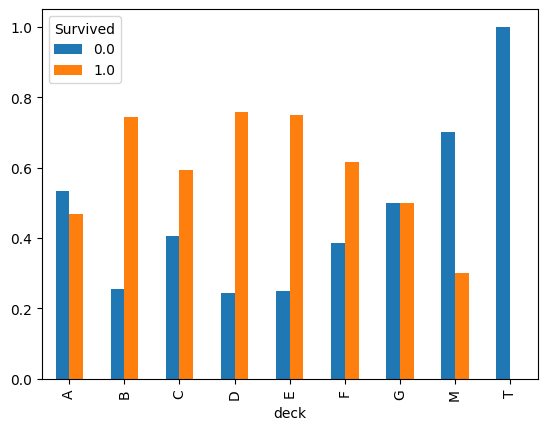

In [111]:
pd.crosstab(df['deck'], df['Survived'] , normalize='index').plot(kind='bar')

## *Conclusion* ->
- There was very less chance for the passengers at the lower decks to survive.
- Passengers at upper and middle decks had a fine probability of surviving.